# Correlations in v2 ELAsTiCC data (based on "Fink case study: ELASTiCC data")

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import glob
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

In [3]:
from orphans.correlations import MinimalMagnitude, PeakTime, DurationBetweenFirstAndPeak, Rate, Color, Heatmap

## Load data

Let's assume you downloaded data from the Fink Data Transfer service. You can read the data using pandas (the data are loaded in several steps because they make the kernel crash...):

In [4]:
# SN-like alerts

list_df = []

for i in range(2,6):
    list_df.append(pd.read_parquet(f'orphans/data/elasticc/ftransfer_elasticc_v2_2023-09-07_396476/classId=222{i}'))

In [5]:
# fast
for i in range(2,5):
    list_df.append(pd.read_parquet(f'orphans/data/elasticc/ftransfer_elasticc_v2_2023-09-07_396476/classId=223{i}'))

In [6]:
# long
for i in range(2,6):
    list_df.append(pd.read_parquet(f'orphans/data/elasticc/ftransfer_elasticc_v2_2023-09-07_396476/classId=224{i}'))

In [7]:
# periodic
for i in range(2,5):
    list_df.append(pd.read_parquet(f'orphans/data/elasticc/ftransfer_elasticc_v2_2023-09-07_396476/classId=232{i}'))

In [8]:
# AGN
list_df.append(pd.read_parquet(f'orphans/data/elasticc/ftransfer_elasticc_v2_2023-09-07_396476/classId=2332'))

In [9]:
pdf = pd.concat(list_df)

In [10]:
pdf.head(5)

,alertId,diaSource,prvDiaSources,prvDiaForcedSources,diaObject,topic,brokerIngestTimestamp,timestamp,year,month,day
0,5606854002,"{'decl': 3.134927, 'diaObjectId': 2803427, 'di...","[{'decl': 3.134927, 'diaObjectId': 2803427, 'd...",[],"{'decl': 3.134927, 'diaObjectId': 2803427, 'ho...",elasticc2-training-20230613-2222,2023-06-15 08:43:39.918889,2023-12-11 08:58:30.72,2023,12,11
1,34247498002,"{'decl': -37.544325, 'diaObjectId': 17123749, ...","[{'decl': -37.544325, 'diaObjectId': 17123749,...","[{'diaForcedSourceId': 34247498000, 'diaObject...","{'decl': -37.544325, 'diaObjectId': 17123749, ...",elasticc2-training-20230613-2222,2023-06-15 09:01:12.770804,2023-12-11 02:25:40.8,2023,12,11
2,136799776003,"{'decl': -25.44773, 'diaObjectId': 68399888, '...","[{'decl': -25.44773, 'diaObjectId': 68399888, ...","[{'diaForcedSourceId': 136799776000, 'diaObjec...","{'decl': -25.44773, 'diaObjectId': 68399888, '...",elasticc2-training-20230613-2222,2023-06-15 10:05:37.037108,2023-12-11 03:08:26.88,2023,12,11
3,57876390004,"{'decl': -34.048594, 'diaObjectId': 28938195, ...","[{'decl': -34.048594, 'diaObjectId': 28938195,...","[{'diaForcedSourceId': 57876390000, 'diaObject...","{'decl': -34.048594, 'diaObjectId': 28938195, ...",elasticc2-training-20230613-2222,2023-06-15 09:15:48.492042,2023-12-11 02:24:23.04,2023,12,11
4,96165884002,"{'decl': -17.270005, 'diaObjectId': 48082942, ...","[{'decl': -17.270005, 'diaObjectId': 48082942,...","[{'diaForcedSourceId': 96165884000, 'diaObject...","{'decl': -17.270005, 'diaObjectId': 48082942, ...",elasticc2-training-20230613-2222,2023-06-15 09:40:08.320749,2023-12-11 03:33:04.32,2023,12,11


In [11]:
print(pdf.keys())

Index(['alertId', 'diaSource', 'prvDiaSources', 'prvDiaForcedSources',
       'diaObject', 'topic', 'brokerIngestTimestamp', 'timestamp', 'year',
       'month', 'day'],
      dtype='object')


## Reconstruct alert light-curves

In [12]:
def extract_history(history_list: list, field: str) -> list:
    """Extract the historical measurements contained in the alerts
    for the parameter `field`.

    Parameters
    ----------
    history_list: list of dict
        List of dictionary from alert[history].
    field: str
        The field name for which you want to extract the data. It must be
        a key of elements of history_list
    
    Returns
    ----------
    measurement: list
        List of all the `field` measurements contained in the alerts.
    """
    if history_list is None:
        return []
    try:
        measurement = [obs[field] for obs in history_list]
    except KeyError:
        print('{} not in history data'.format(field))
        measurement = []

    return measurement

def extract_field(alert: dict, category: str, field: str) -> np.array:
    """ Concatenate current and historical observation data for a given field.
    
    Parameters
    ----------
    alert: dict
        Dictionnary containing alert data
    category: str
        prvDiaSources or prvDiaForcedSources
    field: str
        Name of the field to extract.
    
    Returns
    ----------
    data: np.array
        List containing previous measurements and current measurement at the
        end. If `field` is not in the category, data will be
        [alert['diaSource'][field]].
    """
    data = np.concatenate(
        [
            [alert["diaSource"][field]],
            extract_history(alert[category], field)
        ]
    )
    return data

def flux_to_mag(flux):
    """ Convert calibrated flux in magnitude according to mag(LSST-alert) = 31.4 - 2.5*log10(psFlux)
    
    Parameters
    ----------
    flux: list
        List containing the calibrated flux ('psFlux')
        
    Returns
    ----------
    mag: list
        List containing the magnitude
    """
    mag = 31.4 - 2.5 * np.log10(flux)
    
    return mag

In [13]:
# Standard fluxes
pdf['cpsFlux'] = pdf[['diaSource', 'prvDiaForcedSources']]\
    .apply(lambda x: extract_field(x, 'prvDiaForcedSources', 'psFlux'), axis=1)
pdf['cpsFluxErr'] = pdf[['diaSource', 'prvDiaForcedSources']]\
    .apply(lambda x: extract_field(x, 'prvDiaForcedSources', 'psFluxErr'), axis=1)
pdf['filt'] = pdf[['diaSource', 'prvDiaForcedSources']]\
    .apply(lambda x: extract_field(x, 'prvDiaForcedSources', 'filterName'), axis=1)
pdf['time'] = pdf[['diaSource', 'prvDiaForcedSources']]\
    .apply(lambda x: extract_field(x, 'prvDiaForcedSources', 'midPointTai'), axis=1)

# orphans magnitudes
pdf['mags'] = pdf['cpsFlux'].apply(lambda x: flux_to_mag(x))
pdf['mags_err_max'] = pdf[['cpsFlux', 'cpsFluxErr']].apply(lambda x: flux_to_mag(x.cpsFlux+x.cpsFluxErr), axis=1)
pdf['mags_err'] = pdf['mags']-pdf['mags_err_max']
pdf['mag_peak'] = pdf['mags'].apply(lambda x: min(x))
#pdf['mag_peak'] = pdf[['PEAKMAG_u', 'PEAKMAG_g', 'PEAKMAG_r', 'PEAKMAG_i', 'PEAKMAG_z', 'PEAKMAG_Y']].min(axis=1)


cols = ['alertId', 'time', 'cpsFlux', 'cpsFluxErr', 'filt', 'mags', 'mags_err', 'mag_peak']
sub = pdf[cols]

# adding a column for the theoretical LSST limiting magnitude
sub['mags_lim'] = 24.5
sub['first_detect'] = pdf['time'].apply(lambda x: min(x))
sub

/tmp/ipykernel_23494/952164798.py:68: RuntimeWarning: invalid value encountered in log10
  mag = 31.4 - 2.5 * np.log10(flux)
/tmp/ipykernel_23494/3474904812.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['mags_lim'] = 24.5
/tmp/ipykernel_23494/3474904812.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['first_detect'] = pdf['time'].apply(lambda x: min(x))


,alertId,time,cpsFlux,cpsFluxErr,filt,mags,mags_err,mag_peak,mags_lim,first_detect
0,5606854002,[60289.3323],[1665.259033203125],[239.58059692382812],[i],[23.346295504582155],[0.1459415495158538],23.346296,24.5,60289.3323
1,34247498002,"[60289.0595, 60282.0256, 60282.0388]","[1467.334228515625, 1730.736328125, 1792.16137...","[155.61282348632812, 263.3451232910156, 286.87...","[r, r, i]","[23.483677378876326, 23.30442272598252, 23.266...","[0.10943825731055057, 0.15377996044274767, 0.1...",23.266557,24.5,60282.0256
2,136799776003,"[60289.0892, 60282.0515, 60282.0759, 60289.0649]","[1169.5867919921875, 1870.805419921875, 1473.9...","[244.07601928710938, 233.5064239501953, 455.73...","[i, i, z, r]","[23.729918861989173, 23.219928451411246, 23.47...","[0.20578344528810888, 0.12770370033095801, 0.2...",23.219928,24.5,60282.0515
3,57876390004,"[60289.0586, 60277.0988, 60277.1237, 60282.050...","[9615.544921875, 9872.345703125, 15432.4443359...","[175.93112182617188, 549.3959350585938, 483.59...","[r, z, i, i, z]","[21.442565247139548, 21.41394911303528, 20.928...","[0.019685661354884587, 0.058799869332531784, 0...",20.928913,24.5,60277.0988
4,96165884002,"[60289.1063, 60287.1106, 60287.1339]","[1678.7730712890625, 2891.4755859375, 9874.166...","[208.82850646972656, 436.58465576171875, 264.5...","[u, u, r]","[23.3375200144906, 22.747201175734, 21.4137489...","[0.1272958436848981, 0.15267912302648057, 0.02...",21.413749,24.5,60287.1106
...,...,...,...,...,...,...,...,...,...,...
186710,55440150003,"[60292.3547, 60277.3504, 60289.3419, 60292.343]","[5455.94384765625, 3470.41552734375, -3174.189...","[1231.35498046875, 1268.174560546875, 280.3555...","[Y, Y, i, Y]","[22.05782527017262, 22.54904630550959, nan, 21...","[0.22095209638159474, 0.3381691596241687, nan,...",21.843704,24.5,60277.3504
186711,7749228019,"[60293.0944, 60275.1831, 60275.1836, 60275.207...","[-943.563232421875, -1478.9462890625, -1562.42...","[150.23194885253906, 433.4325866699219, 443.89...","[r, z, z, Y, Y, i, i, z, z, g, r, i, i, z, z, ...","[nan, nan, nan, nan, nan, 23.430111343146535, ...","[nan, nan, nan, nan, nan, 0.2211525958764362, ...",NaN,24.5,60275.1831
186712,47780916016,"[60293.1003, 60275.146, 60275.1706, 60279.1121...","[-1904.2432861328125, 1415.7635498046875, -199...","[189.70565795898438, 552.4615478515625, 549.90...","[r, i, z, g, r, r, i, r, i, u, g, u, u, r, u, ...","[nan, 23.522523182981736, nan, 22.379339894428...","[nan, 0.3577100964208313, nan, 0.0527928150104...",NaN,24.5,60275.1460
186713,99760032012,"[60292.0573, 60276.0217, 60276.0297, 60276.035...","[-3321.58349609375, -168.55519104003906, 532.6...","[241.7059326171875, 389.19195556640625, 460.22...","[u, r, r, i, i, z, z, Y, Y, r, i, r, g]","[nan, nan, 24.583840257516236, nan, nan, nan, ...","[nan, nan, 0.6761026927414449, nan, nan, nan, ...",NaN,24.5,60276.0217


## Light curves in fluxes

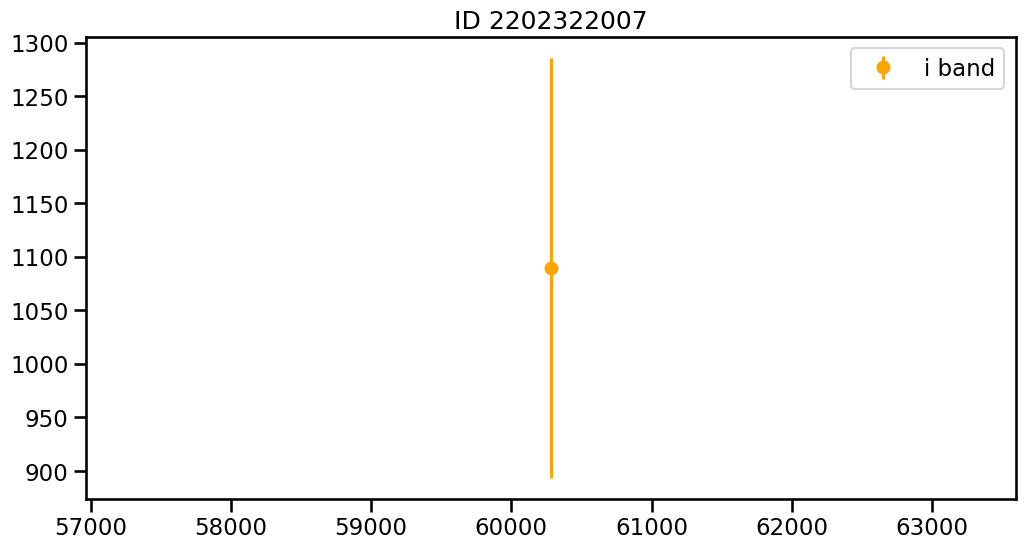

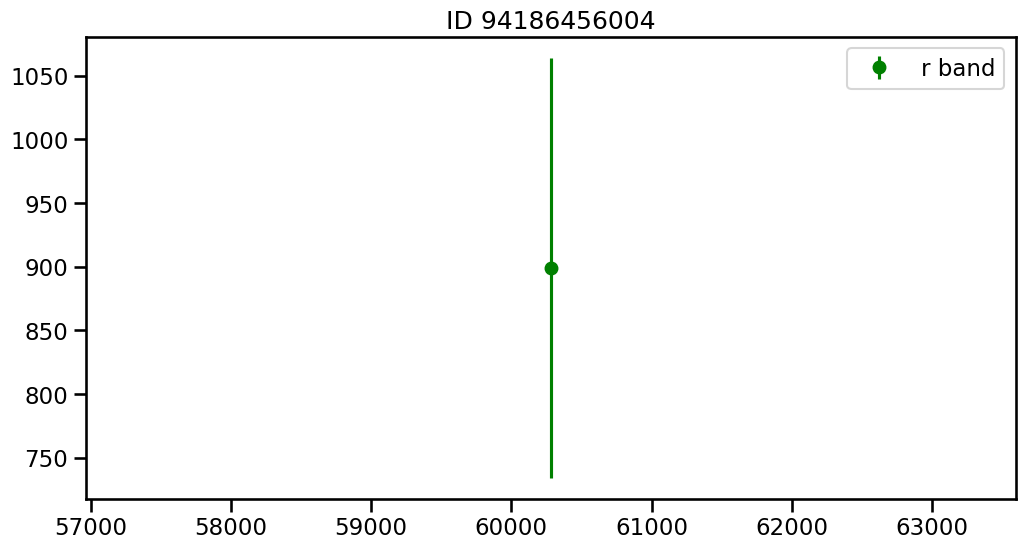

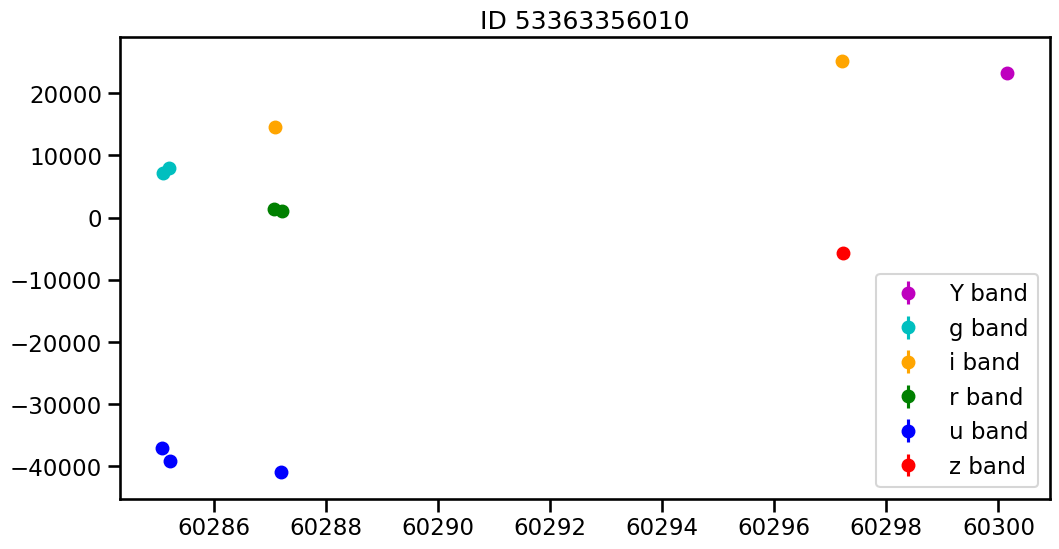

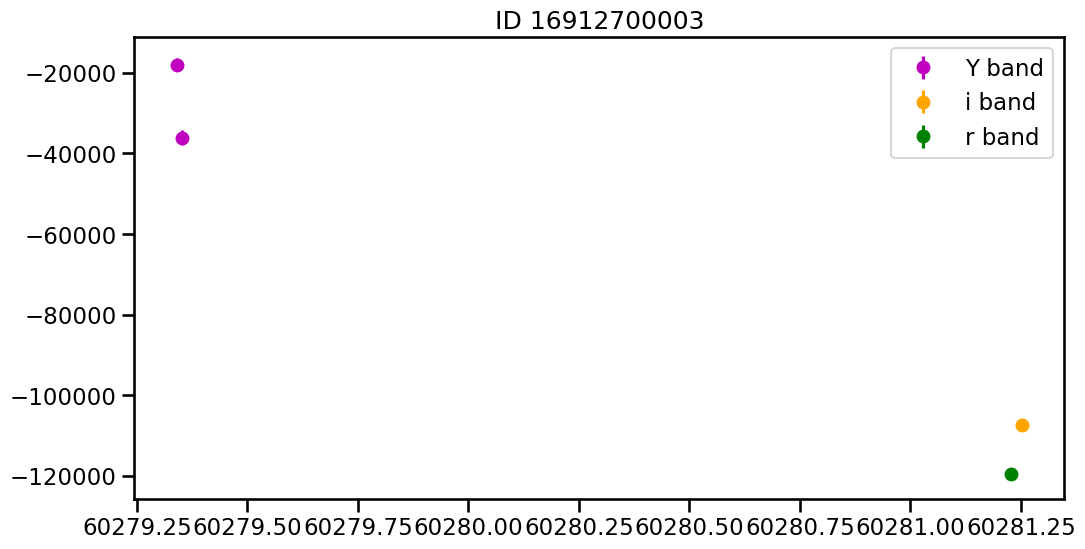

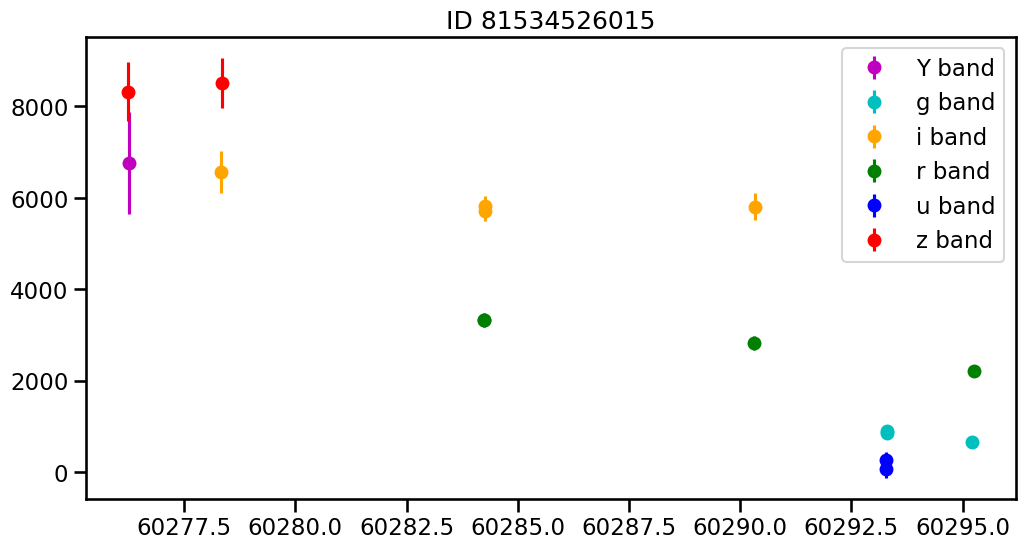

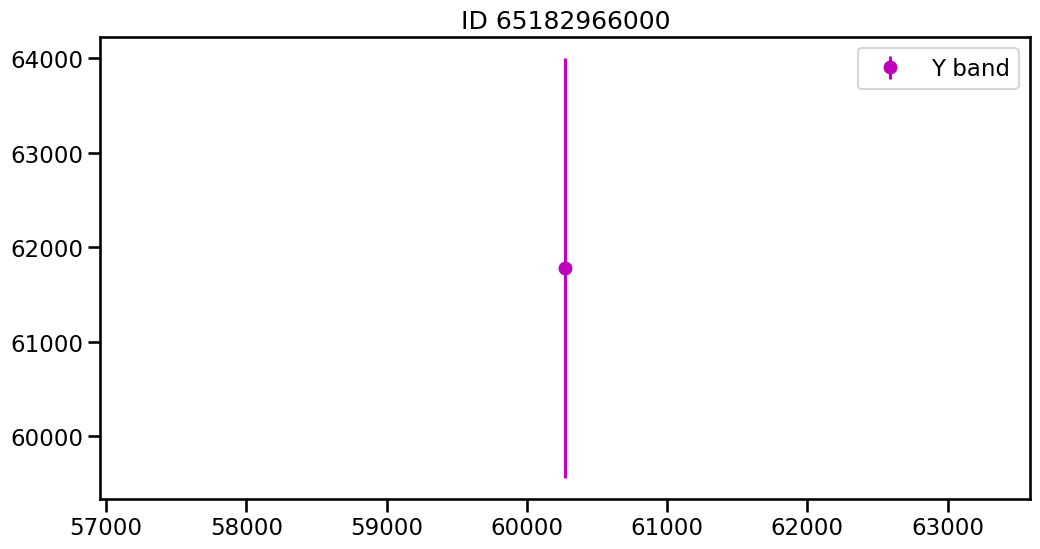

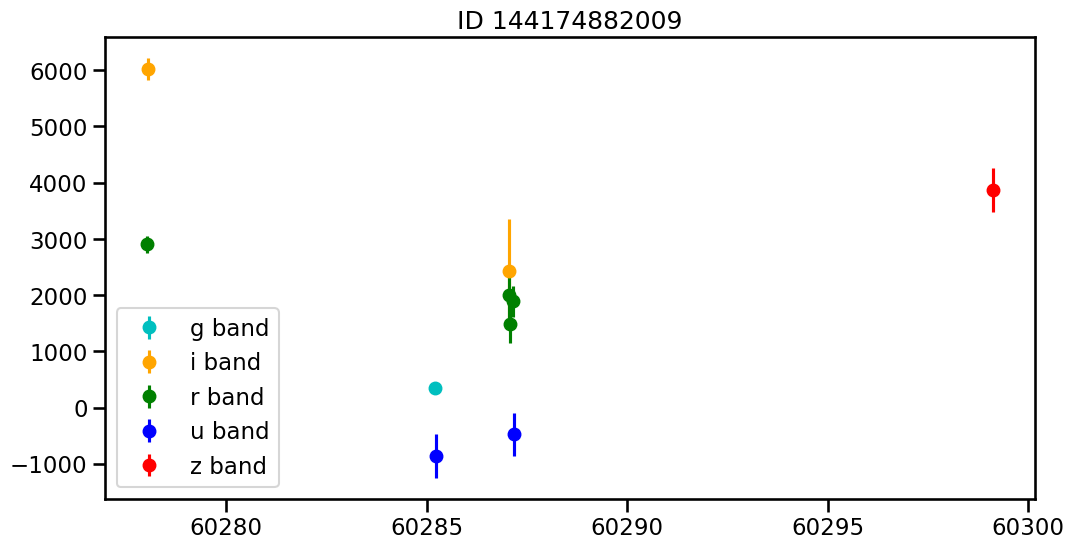

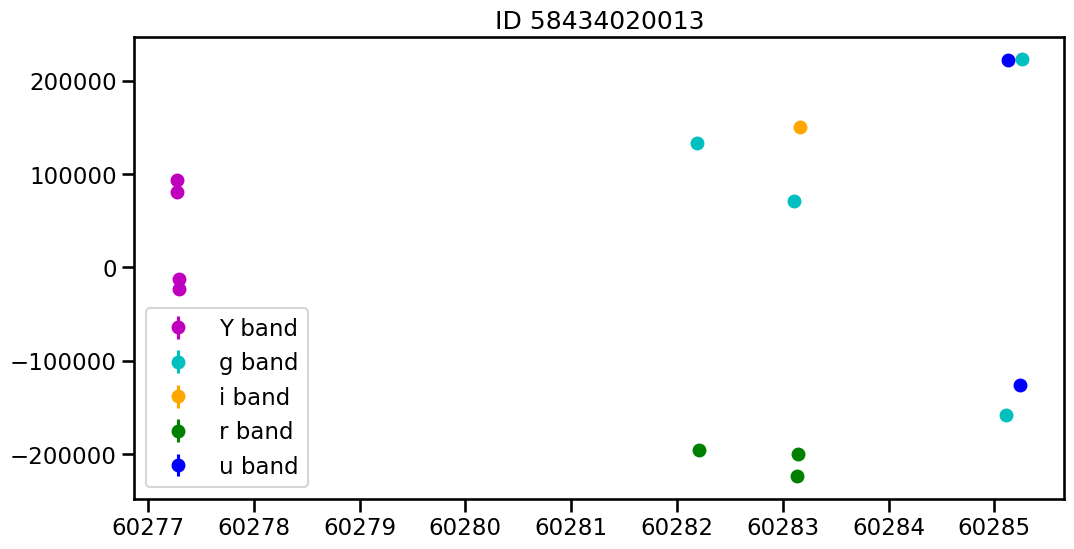

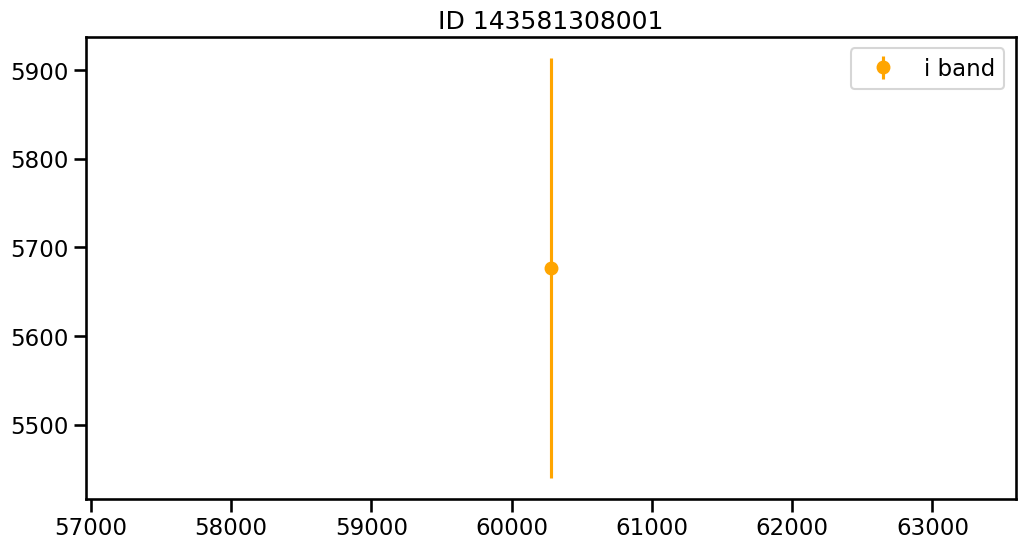

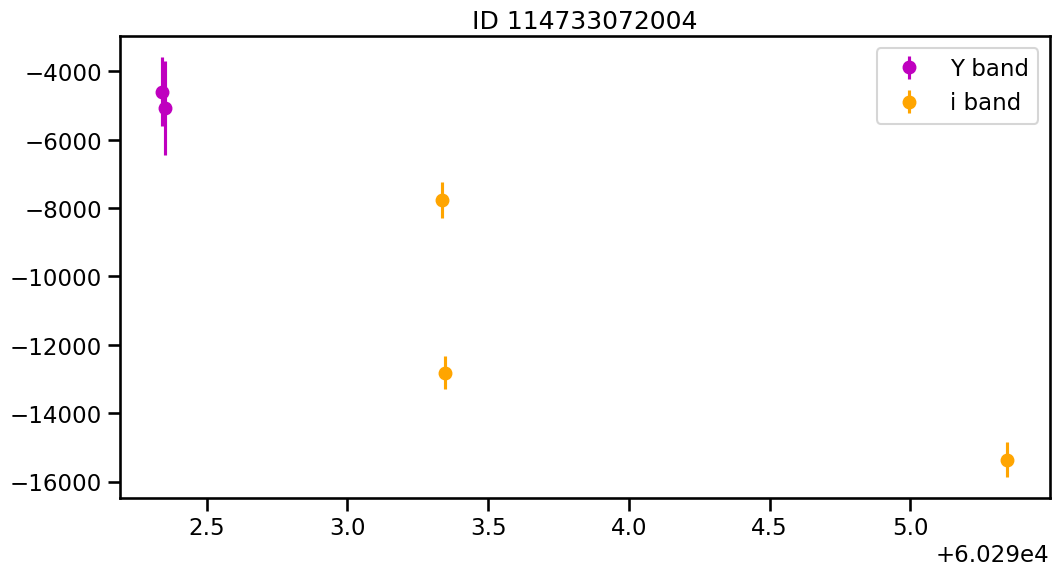

In [14]:
N = 10
seed = np.random.seed(2)
indices = np.random.randint(0, len(sub), N)

filtercolors = {'u': 'b', 'g': 'c', 'r': 'g', 'i': 'orange', 'z': 'r', 'Y': 'm'}

for index in indices:
    fig = plt.figure(figsize=(12, 6))
    
    data = sub.iloc[index]
    filters = np.unique(data['filt'])
    
    for filt in filters:
        cond = data['filt'] == filt
        
        plt.errorbar(
            data['time'][cond], 
            data['cpsFlux'][cond], 
            data['cpsFluxErr'][cond],
            ls='',
            c=filtercolors[filt],
            marker='o',
            label='{} band'.format(filt)
        )
    plt.title('ID {}'.format(data['alertId']))
    plt.legend()
    plt.show()

You can find the mapping to the taxonomy at https://github.com/LSSTDESC/elasticc/blob/main/taxonomy/taxonomy.ipynb

## Light curves in magnitudes

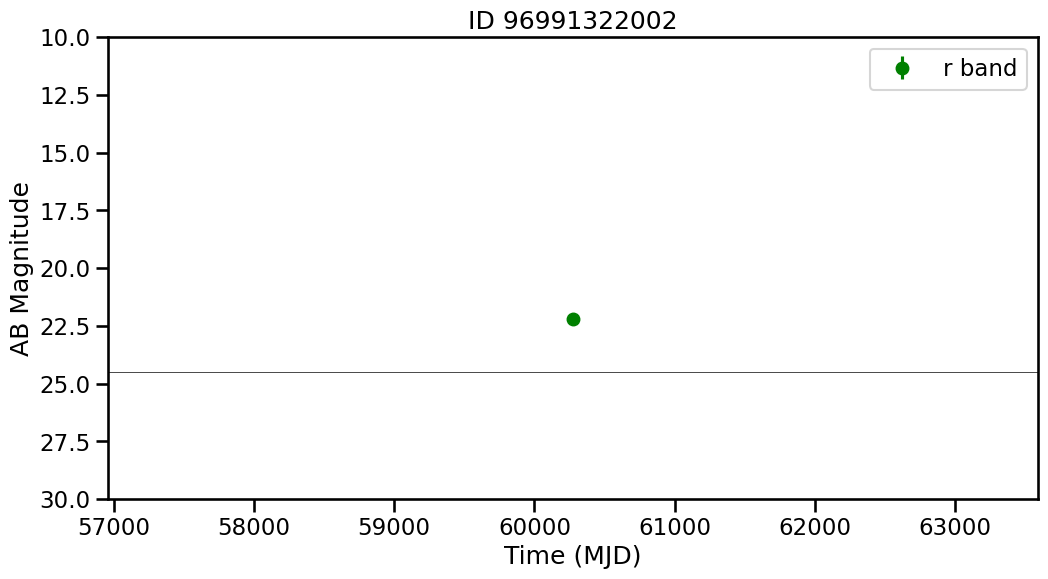

anaconda3/envs/orphans/lib/python3.9/site-packages/matplotlib/axes/_base.py:2480: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


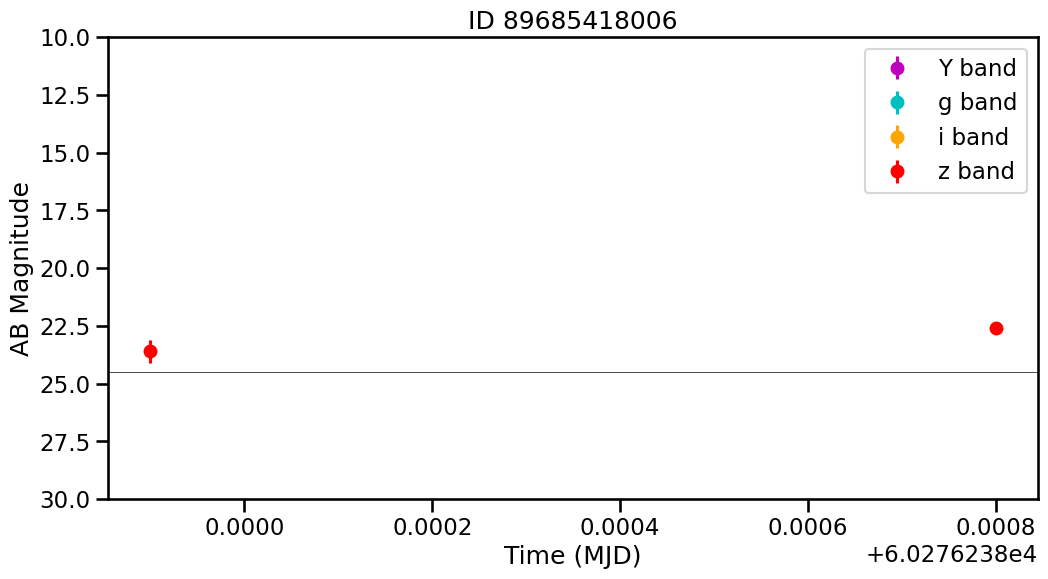

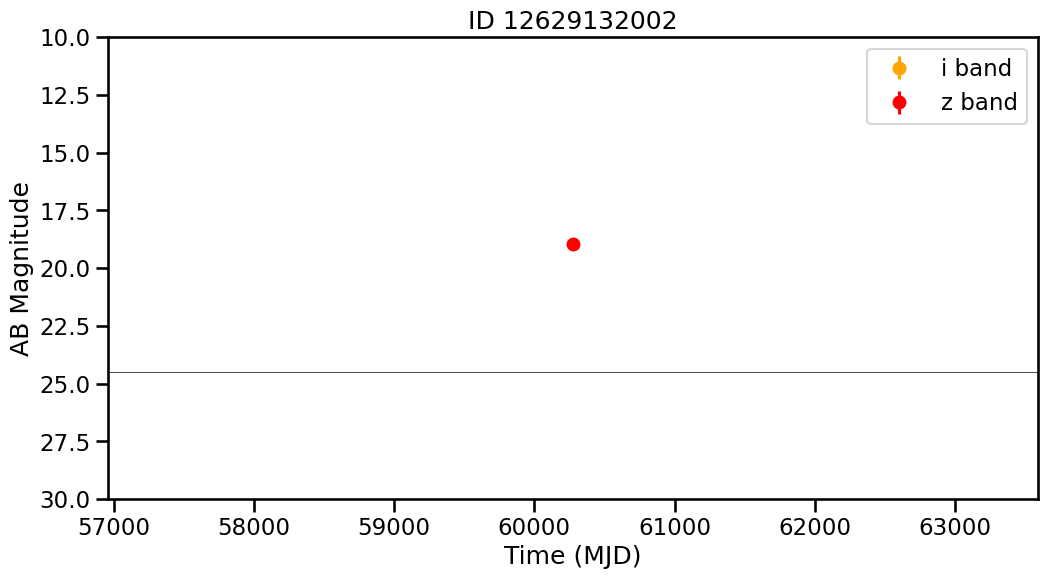

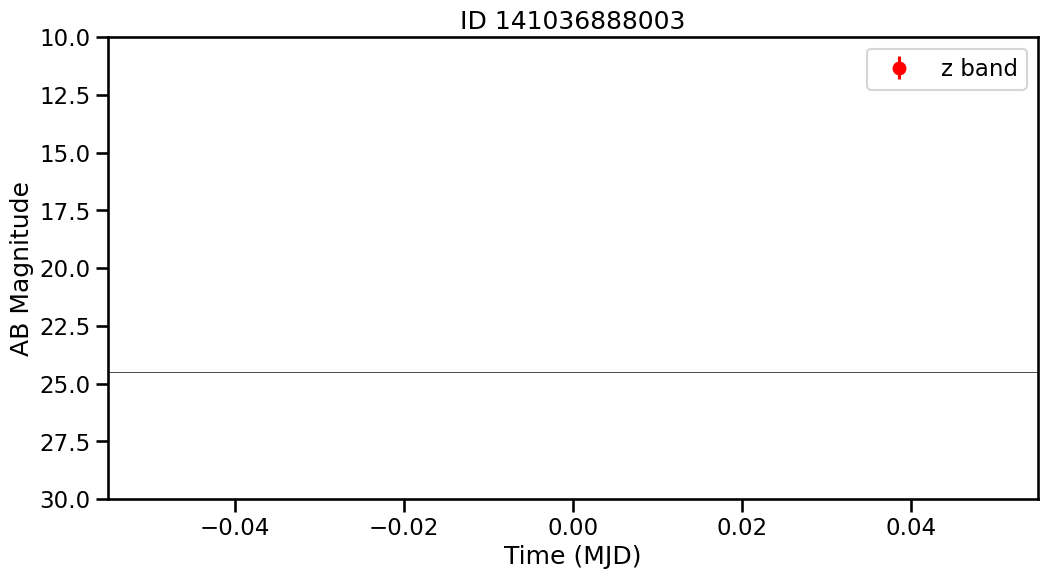

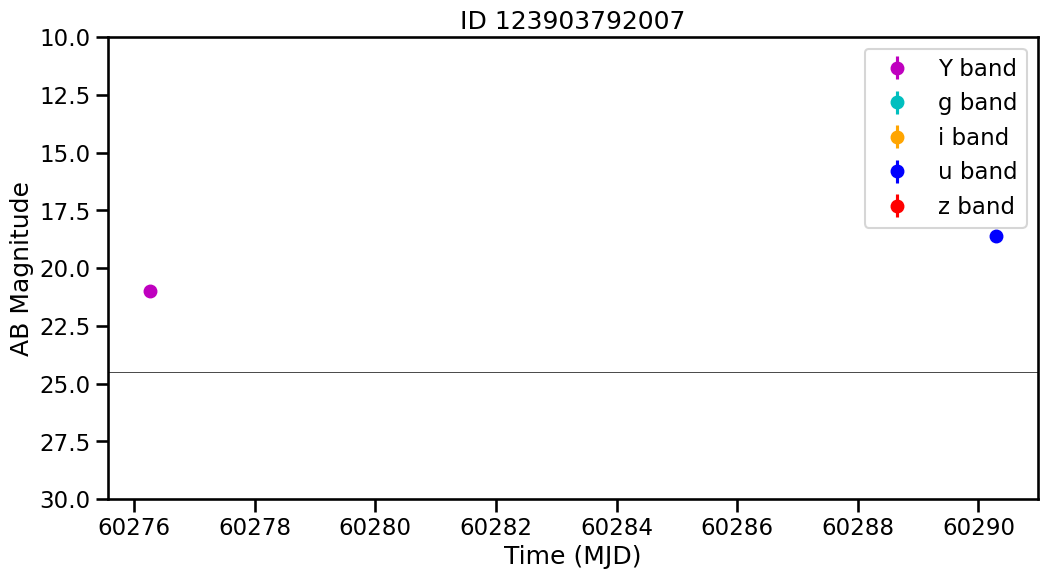

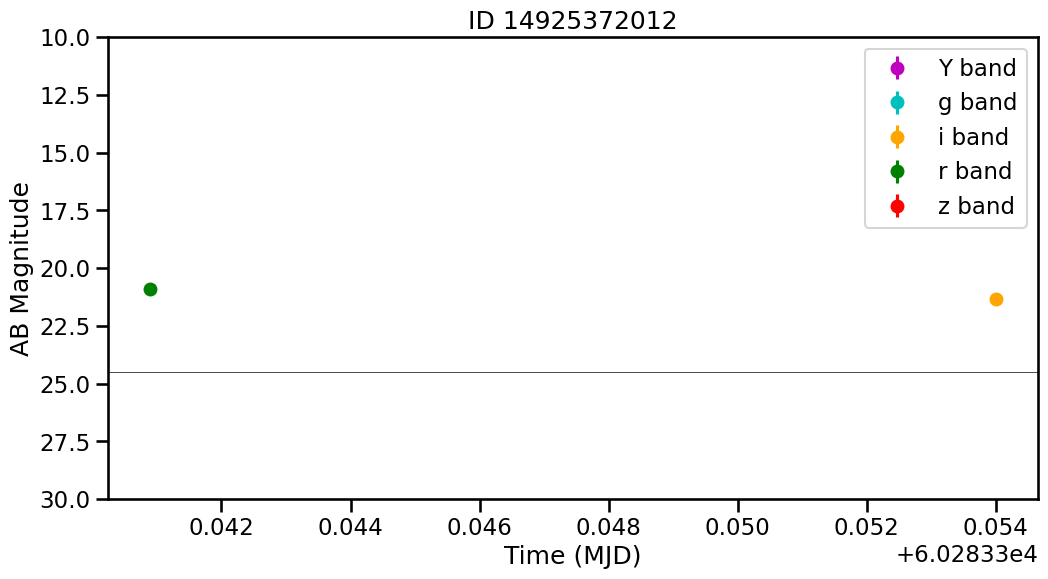

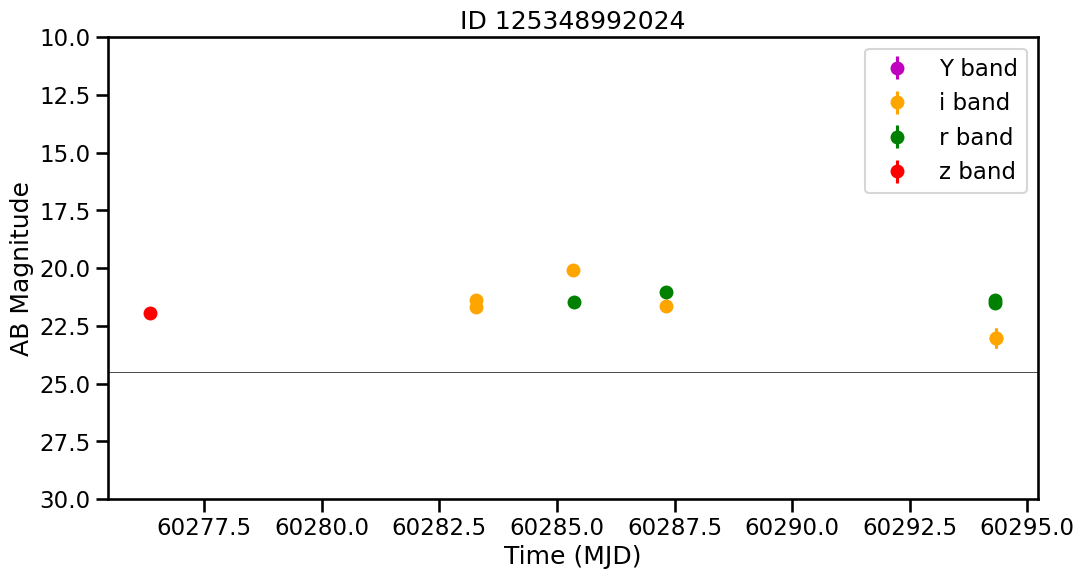

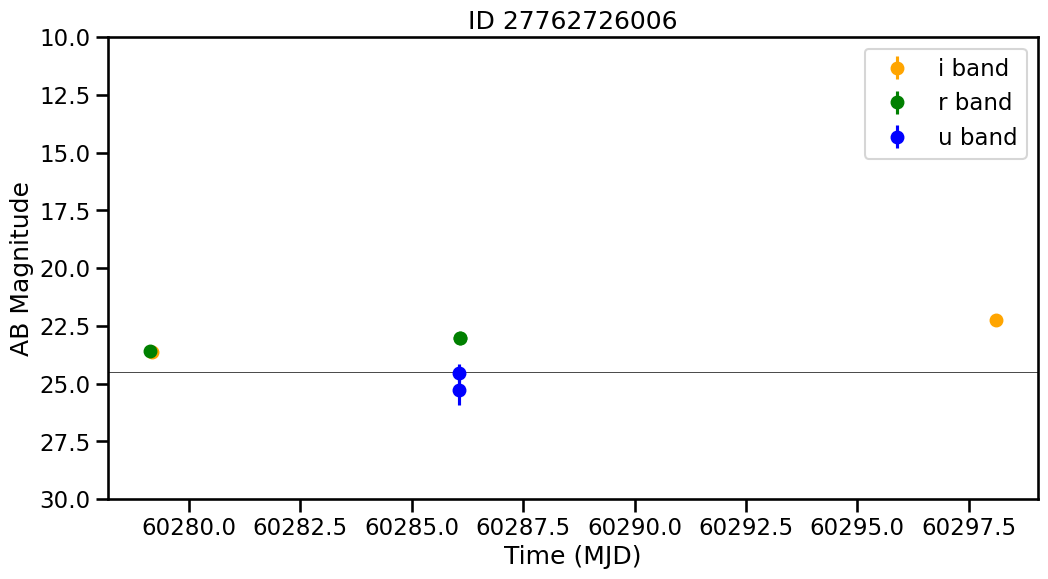

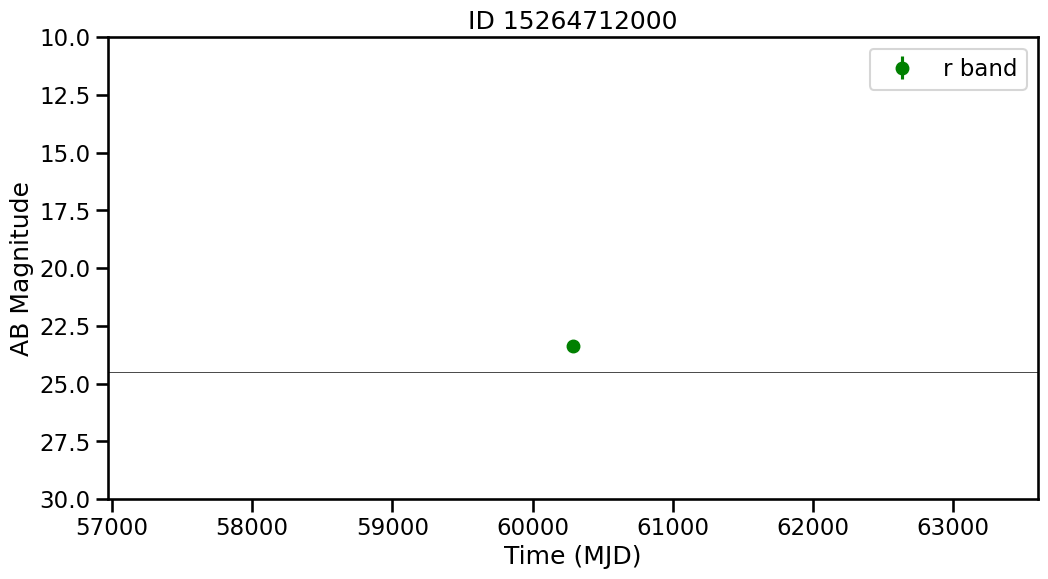

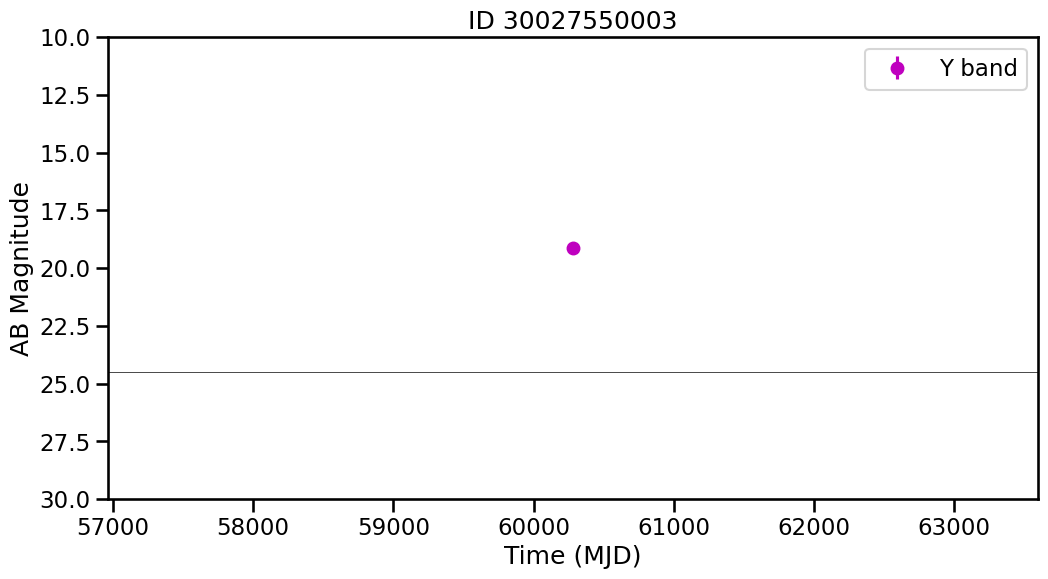

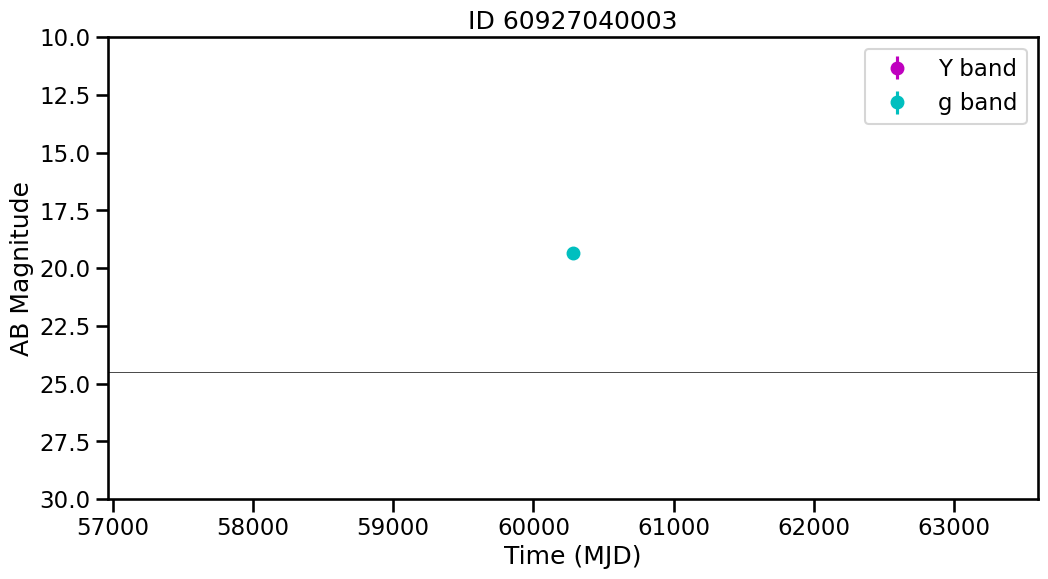

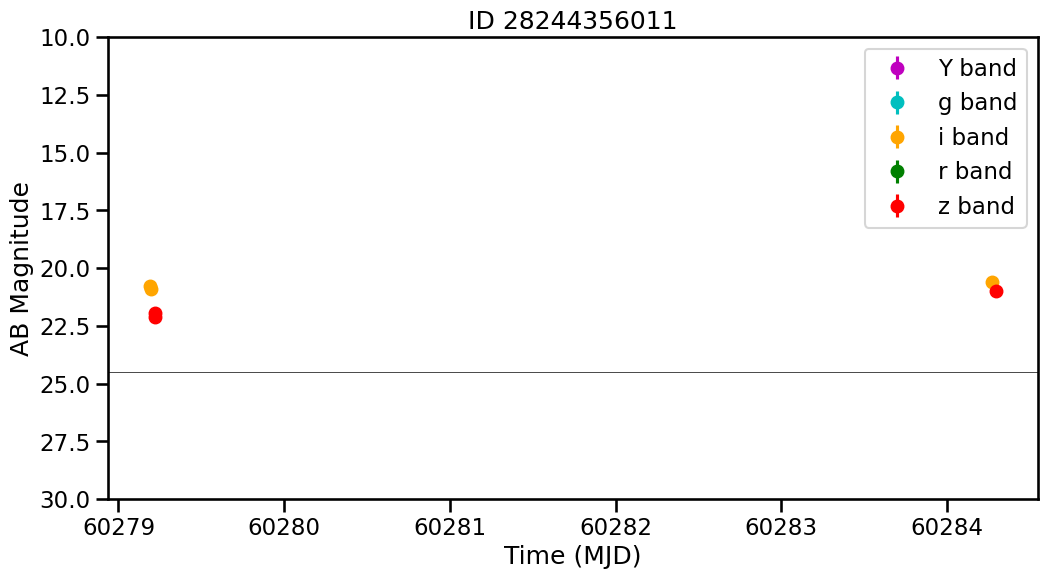

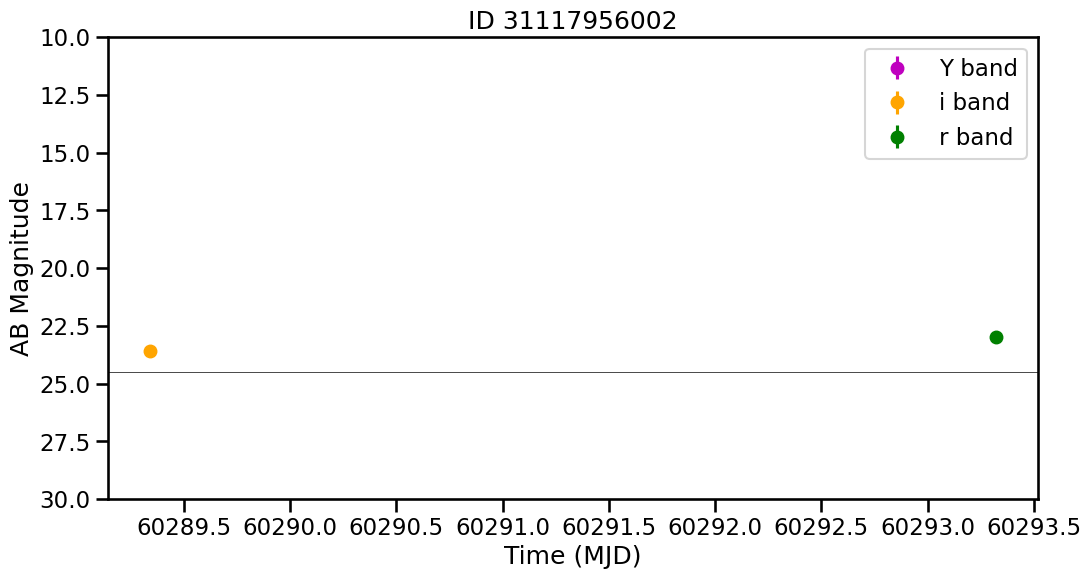

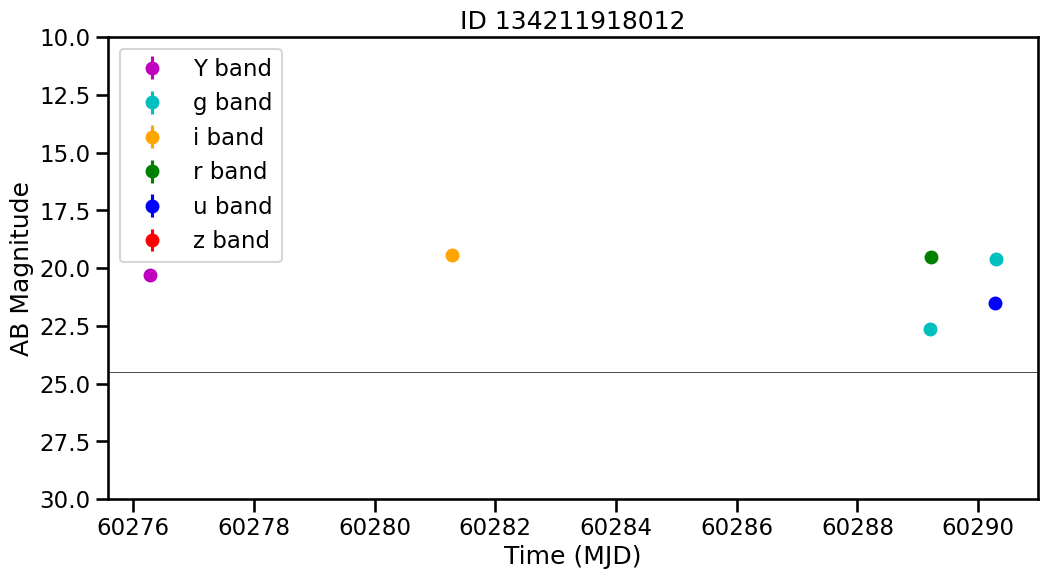

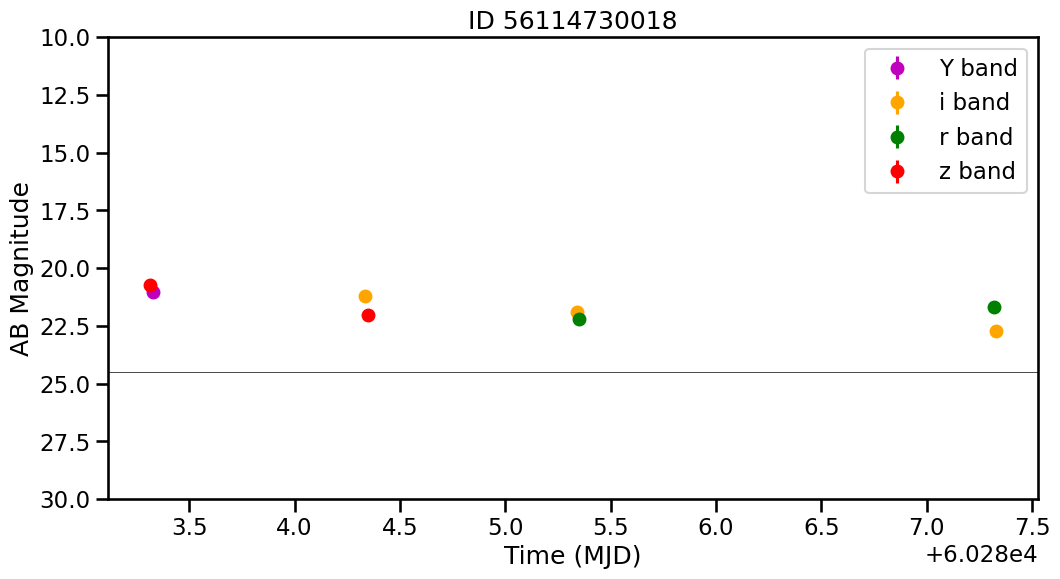

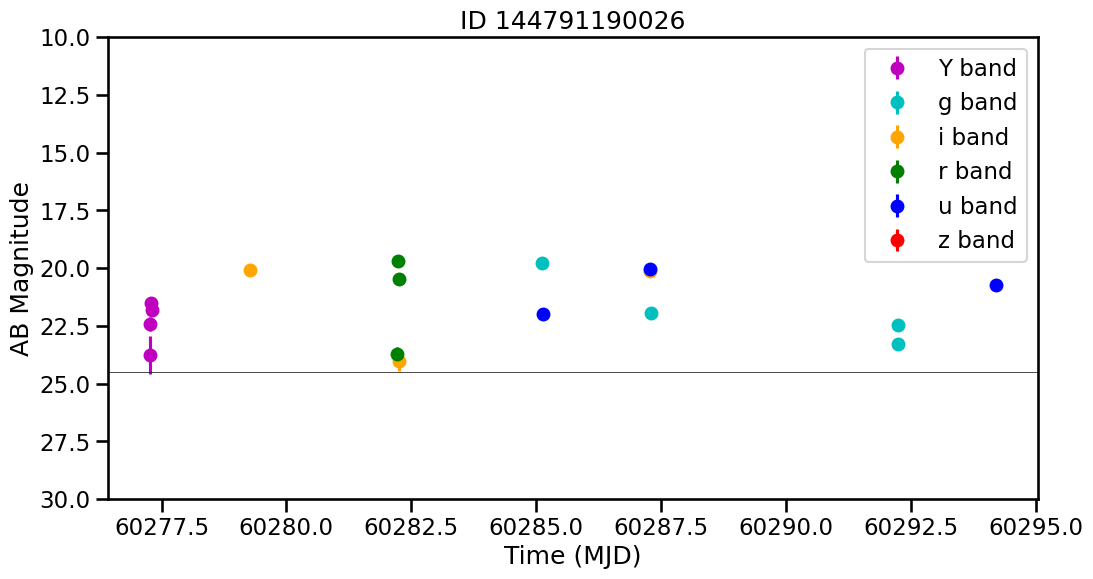

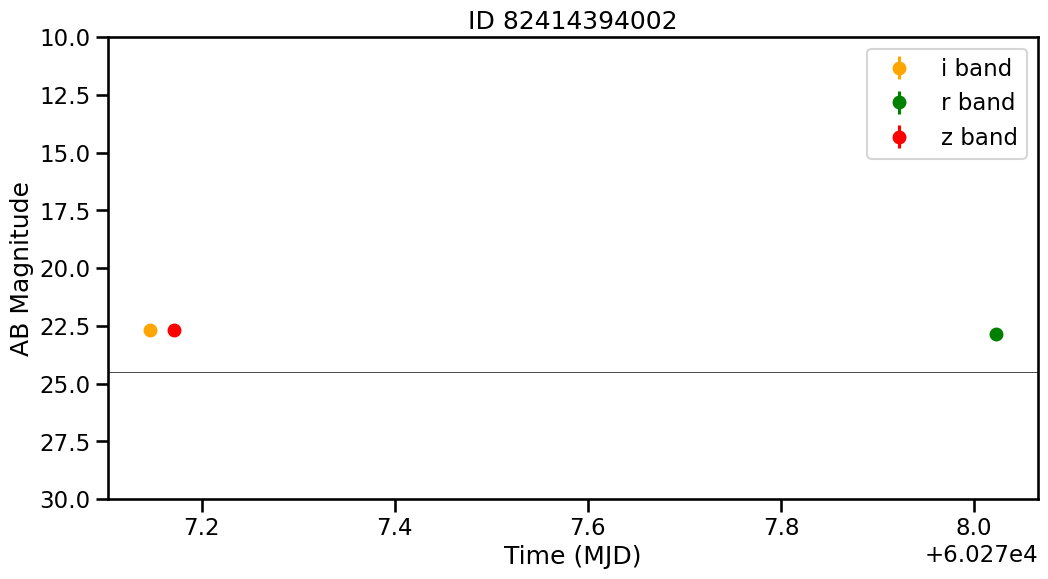

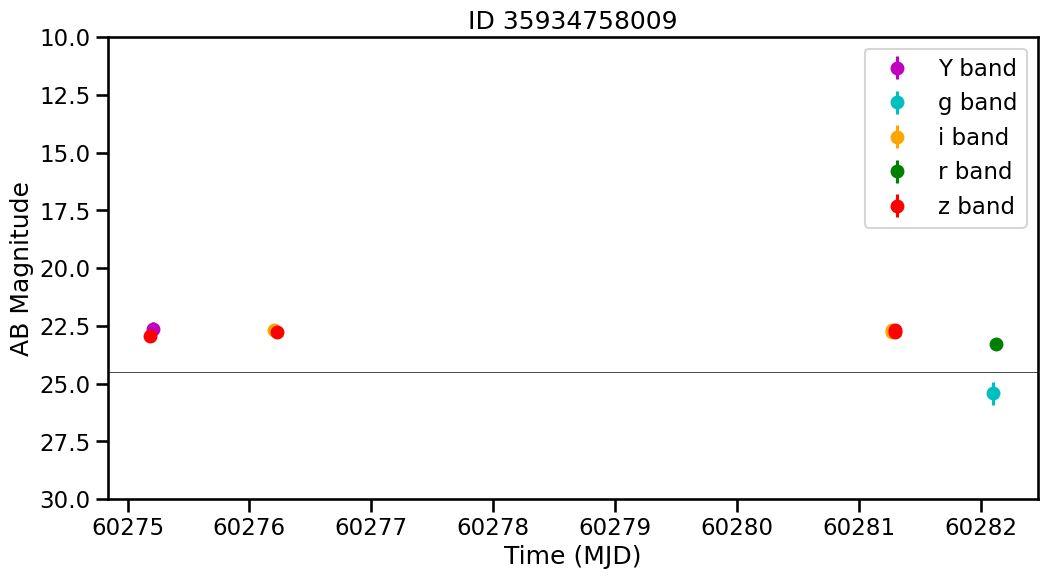

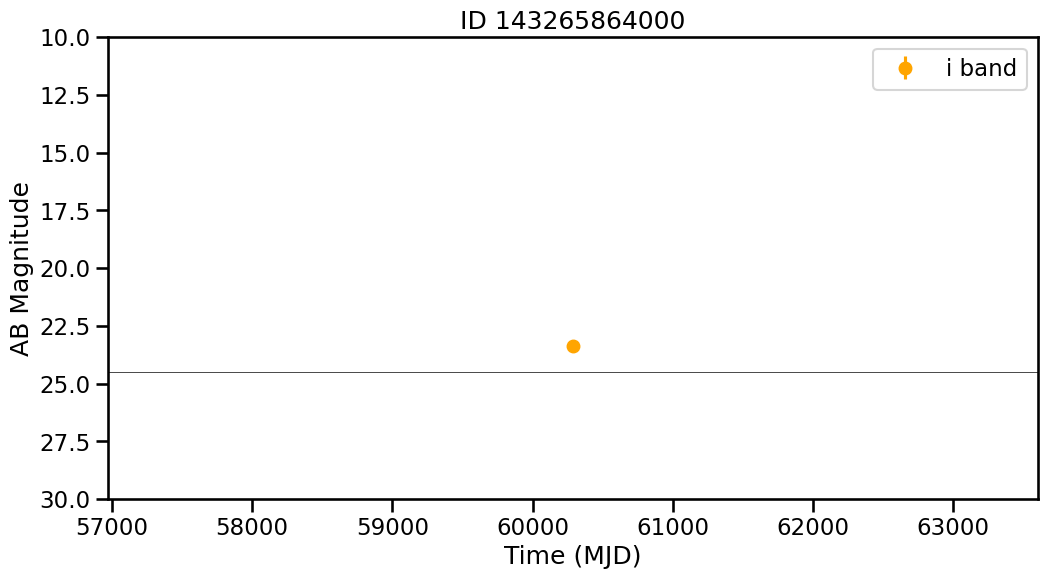

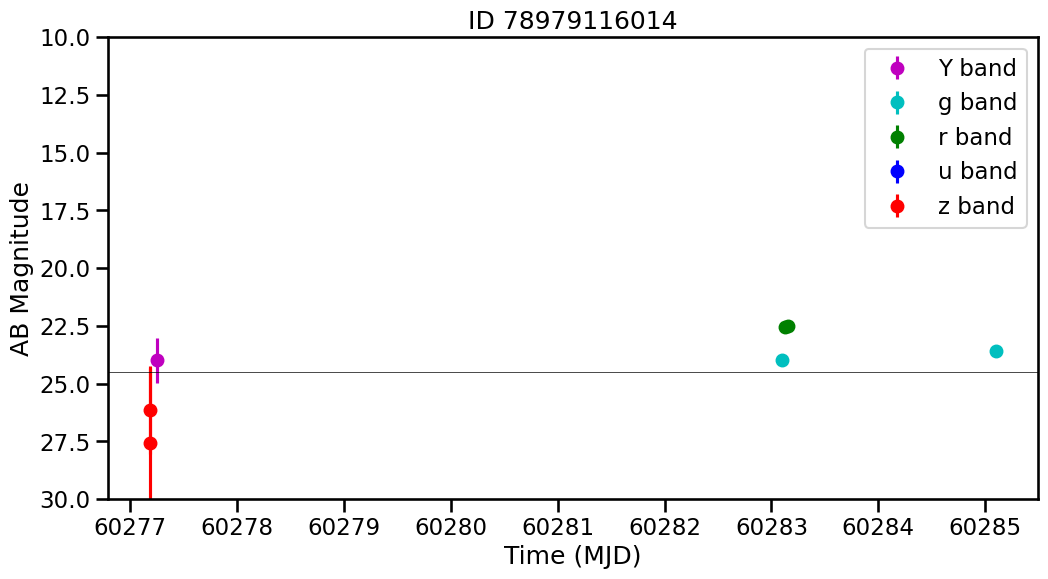

In [15]:
N = 20
seed = np.random.seed(3)
indices = np.random.randint(0, len(sub), N)

filtercolors = {'u': 'b', 'g': 'c', 'r': 'g', 'i': 'orange', 'z': 'r', 'Y': 'm'}

for index in indices:
    fig = plt.figure(figsize=(12, 6))
    
    data = sub.iloc[index]
    filters = np.unique(data['filt'])
    
    for filt in filters:
        cond = data['filt'] == filt
        
        plt.errorbar(
            data['time'][cond], 
            data['mags'][cond], 
            data['mags_err'][cond],
            ls='',
            c=filtercolors[filt],
            marker='o',
            label='{} band'.format(filt)
        )

    plt.title('ID {}'.format(data['alertId']))
    plt.legend()
    plt.xlabel('Time (MJD)')
    plt.ylabel('AB Magnitude')
    plt.gca().invert_yaxis()
    plt.ylim(30, 10)
    plt.axhline(y=24.5, color='black', linewidth=0.5, label='Rubin/LSST nightly limiting magnitude')

    plt.show()

## Calculate features and correlations

In [16]:
# convert sub DataFrame to a list of dictionaries to respect the format used by the correlation functions
sub_list = sub.to_dict('records')

In [17]:
mag_peak = sub['mag_peak']

In [18]:
peak_time = PeakTime(sub_list, data='elasticc')

In [19]:
color = Color(sub_list, data='elasticc')

color_core = [x if x > -0.5 and x < 1.5 else np.nan for x in color]

In [20]:
i, d1, d3 = Rate(sub_list, data='elasticc')

i_core = [[x if x > -0.5 else np.nan for x in i[j]] for j in range(6)]
d1_core = [[x if x < 0.5 else np.nan for x in d1[j]] for j in range(6)]
d3_core = [[x if x < 0.4 else np.nan for x in d3[j]] for j in range(6)]

In [21]:
df_features = pd.DataFrame({'alertId': sub['alertId'], 
                            'time_peak' : peak_time, 
                            'color' : color,
                            'rate_dec_1' : np.nanmean(d1, axis=0),
                            'rate_dec_3' : np.nanmean(d3, axis=0),
                            'rate_inc' : np.nanmean(i, axis=0)}
                          )

sub = pd.merge(sub, df_features, on='alertId')
sub['dt'] = sub['time_peak']-sub['first_detect']
sub

/tmp/ipykernel_23494/2138427468.py:4: RuntimeWarning: Mean of empty slice
  'rate_dec_1' : np.nanmean(d1, axis=0),
/tmp/ipykernel_23494/2138427468.py:5: RuntimeWarning: Mean of empty slice
  'rate_dec_3' : np.nanmean(d3, axis=0),
/tmp/ipykernel_23494/2138427468.py:6: RuntimeWarning: Mean of empty slice
  'rate_inc' : np.nanmean(i, axis=0)}


,alertId,time,cpsFlux,cpsFluxErr,filt,mags,mags_err,mag_peak,mags_lim,first_detect,time_peak,color,rate_dec_1,rate_dec_3,rate_inc,dt
0,5606854002,[60289.3323],[1665.259033203125],[239.58059692382812],[i],[23.346295504582155],[0.1459415495158538],23.346296,24.5,60289.3323,60289.3323,NaN,NaN,NaN,NaN,0.0000
1,34247498002,"[60289.0595, 60282.0256, 60282.0388]","[1467.334228515625, 1730.736328125, 1792.16137...","[155.61282348632812, 263.3451232910156, 286.87...","[r, r, i]","[23.483677378876326, 23.30442272598252, 23.266...","[0.10943825731055057, 0.15377996044274767, 0.1...",23.266557,24.5,60282.0256,60282.0388,NaN,NaN,NaN,NaN,0.0132
2,136799776003,"[60289.0892, 60282.0515, 60282.0759, 60289.0649]","[1169.5867919921875, 1870.805419921875, 1473.9...","[244.07601928710938, 233.5064239501953, 455.73...","[i, i, z, r]","[23.729918861989173, 23.219928451411246, 23.47...","[0.20578344528810888, 0.12770370033095801, 0.2...",23.219928,24.5,60282.0515,60282.0515,NaN,NaN,NaN,NaN,0.0000
3,57876390004,"[60289.0586, 60277.0988, 60277.1237, 60282.050...","[9615.544921875, 9872.345703125, 15432.4443359...","[175.93112182617188, 549.3959350585938, 483.59...","[r, z, i, i, z]","[21.442565247139548, 21.41394911303528, 20.928...","[0.019685661354884587, 0.058799869332531784, 0...",20.928913,24.5,60277.0988,60277.1237,NaN,NaN,NaN,NaN,0.0249
4,96165884002,"[60289.1063, 60287.1106, 60287.1339]","[1678.7730712890625, 2891.4755859375, 9874.166...","[208.82850646972656, 436.58465576171875, 264.5...","[u, u, r]","[23.3375200144906, 22.747201175734, 21.4137489...","[0.1272958436848981, 0.15267912302648057, 0.02...",21.413749,24.5,60287.1106,60287.1339,NaN,NaN,NaN,NaN,0.0233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
797727,55440150003,"[60292.3547, 60277.3504, 60289.3419, 60292.343]","[5455.94384765625, 3470.41552734375, -3174.189...","[1231.35498046875, 1268.174560546875, 280.3555...","[Y, Y, i, Y]","[22.05782527017262, 22.54904630550959, nan, 21...","[0.22095209638159474, 0.3381691596241687, nan,...",21.843704,24.5,60277.3504,60292.3430,NaN,NaN,NaN,NaN,14.9926
797728,7749228019,"[60293.0944, 60275.1831, 60275.1836, 60275.207...","[-943.563232421875, -1478.9462890625, -1562.42...","[150.23194885253906, 433.4325866699219, 443.89...","[r, z, z, Y, Y, i, i, z, z, g, r, i, i, z, z, ...","[nan, nan, nan, nan, nan, 23.430111343146535, ...","[nan, nan, nan, nan, nan, 0.2211525958764362, ...",NaN,24.5,60275.1831,NaN,NaN,NaN,NaN,NaN,NaN
797729,47780916016,"[60293.1003, 60275.146, 60275.1706, 60279.1121...","[-1904.2432861328125, 1415.7635498046875, -199...","[189.70565795898438, 552.4615478515625, 549.90...","[r, i, z, g, r, r, i, r, i, u, g, u, u, r, u, ...","[nan, 23.522523182981736, nan, 22.379339894428...","[nan, 0.3577100964208313, nan, 0.0527928150104...",NaN,24.5,60275.1460,NaN,NaN,NaN,NaN,NaN,NaN
797730,99760032012,"[60292.0573, 60276.0217, 60276.0297, 60276.035...","[-3321.58349609375, -168.55519104003906, 532.6...","[241.7059326171875, 389.19195556640625, 460.22...","[u, r, r, i, i, z, z, Y, Y, r, i, r, g]","[nan, nan, 24.583840257516236, nan, nan, nan, ...","[nan, nan, 0.6761026927414449, nan, nan, nan, ...",NaN,24.5,60276.0217,NaN,NaN,NaN,NaN,NaN,NaN


## Comparison ELAsTiCC data and orphan pseudo-observations

- ELAsTiCC data: 797732 events
- Pseudo-observations: 241678 events

In [22]:
# open pseudo-observations

pseudo_obs = []

for file in glob.glob(f'../data/pseudo_obs/2_millions/short_pseudo_obs_PL_*.pkl'):
    
    file_open = open(str(file), 'rb')
    ps = pickle.load(file_open)
    file_open.close()
    
    pseudo_obs.append(ps)

pseudo_obs = [lc for ps in pseudo_obs for lc in ps if lc != 0]

In [23]:
# minimal magnitude
mag_min = MinimalMagnitude(pseudo_obs)

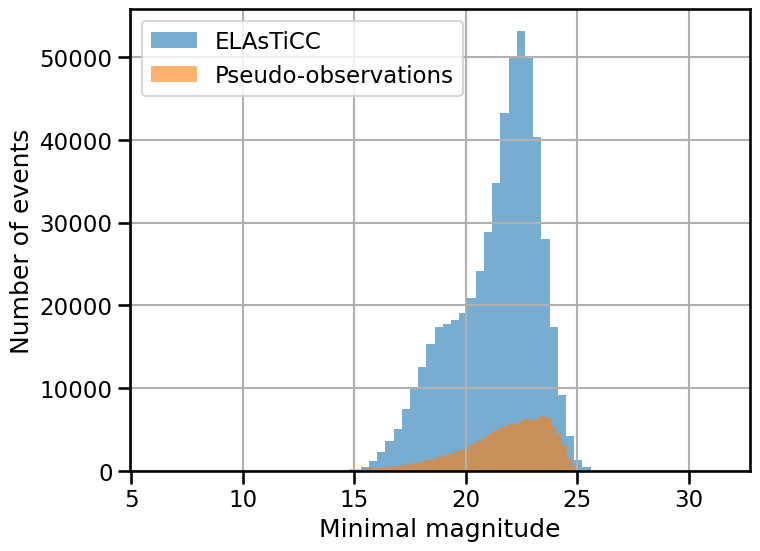

In [24]:
plt.figure(figsize=(8, 6))

sub['mag_peak'].hist(bins=50, alpha=0.6, label='ELAsTiCC')
plt.hist(mag_min, bins=80, alpha=0.6, label='Pseudo-observations');
plt.xlabel('Minimal magnitude')
plt.ylabel('Number of events')
plt.legend()

In [25]:
# duration between the first detection and the minimal magnitude
Dt, t0 = DurationBetweenFirstAndPeak(pseudo_obs)
Dt_mean = np.max(Dt, axis=0)

orphans/orphans/correlations.py:152: RuntimeWarning: All-NaN axis encountered
  if np.nanmin(all_t0) != np.nan:
orphans/orphans/correlations.py:153: RuntimeWarning: All-NaN axis encountered
  t0.append(np.nanmin(all_t0))


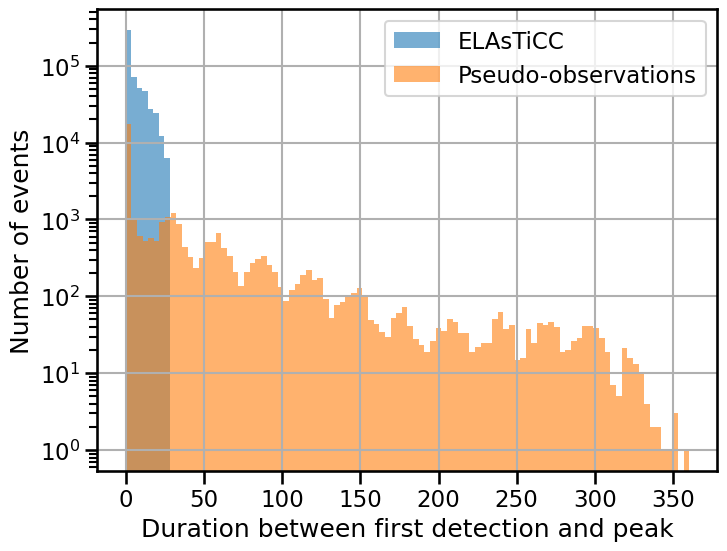

In [26]:
plt.figure(figsize=(8, 6))

sub['dt'].hist(bins=8, alpha=0.6, label='ELAsTiCC')
plt.hist(Dt_mean, bins=100, alpha=0.6, label='Pseudo-observations')

plt.xlabel('Duration between first detection and peak')
plt.ylabel('Number of events')
plt.yscale('log')
plt.legend()

In [27]:
# increase and decrease rates
i, d1, d3 = Rate(pseudo_obs)

In [28]:
i_mean = np.nanmean(i, axis=0)
d1_mean = np.nanmean(d1, axis=0)
d3_mean = np.nanmean(d3, axis=0)

/tmp/ipykernel_23494/541052541.py:1: RuntimeWarning: Mean of empty slice
  i_mean = np.nanmean(i, axis=0)
/tmp/ipykernel_23494/541052541.py:2: RuntimeWarning: Mean of empty slice
  d1_mean = np.nanmean(d1, axis=0)
/tmp/ipykernel_23494/541052541.py:3: RuntimeWarning: Mean of empty slice
  d3_mean = np.nanmean(d3, axis=0)


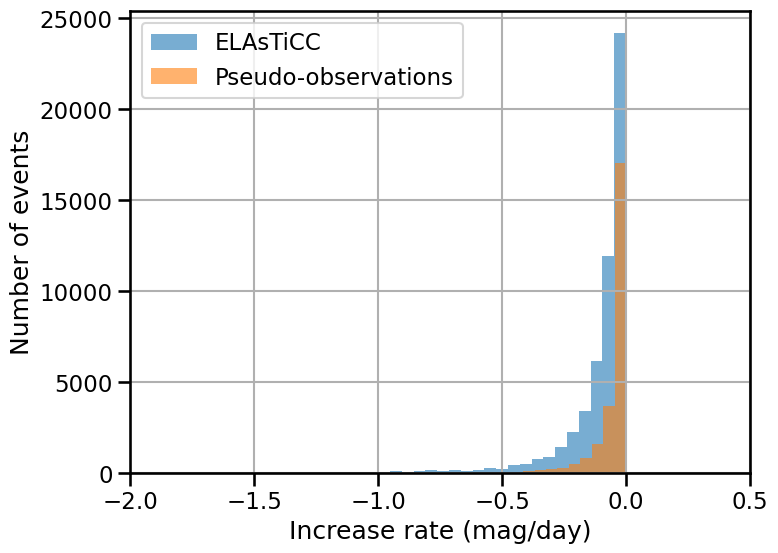

In [29]:
fig = plt.figure(figsize=(8, 6))

sub['rate_inc'].hist(bins=100, alpha=0.6, label='ELAsTiCC')
plt.hist(i_mean, bins=140, alpha=0.6, label='Pseudo-observations');
plt.xlabel('Increase rate (mag/day)')
plt.ylabel('Number of events')
plt.xlim(-2, 0.5)
plt.legend()

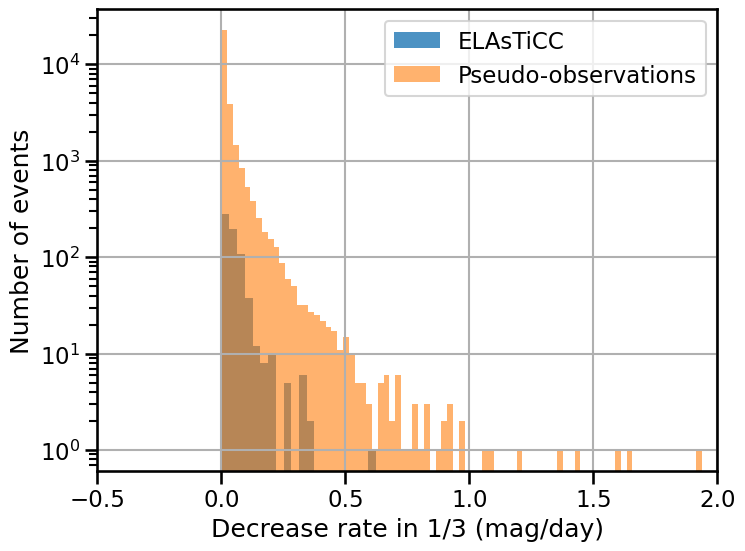

In [30]:
fig = plt.figure(figsize=(8, 6))

sub['rate_dec_1'].hist(bins=20, alpha=0.8, label='ELAsTiCC')
plt.hist(d1_mean, bins=120, alpha=0.6, label='Pseudo-observations')
plt.xlabel('Decrease rate in 1/3 (mag/day)')
plt.ylabel('Number of events')
plt.xlim(-0.5, 2)
plt.yscale('log')
plt.legend()

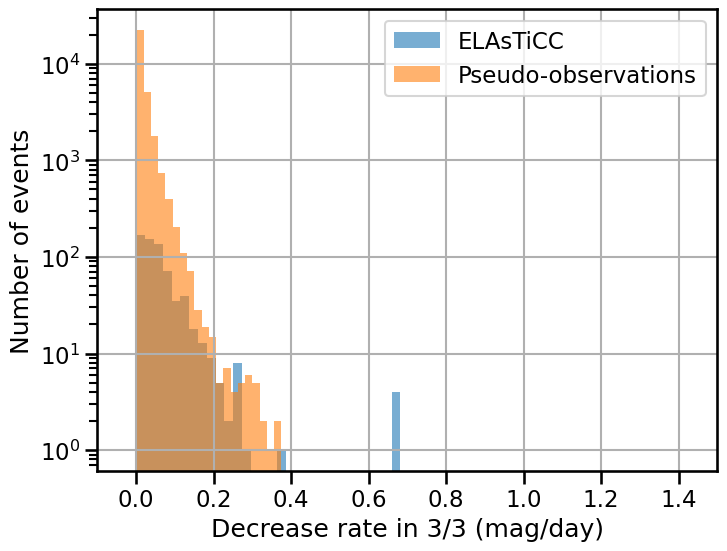

In [31]:
fig = plt.figure(figsize=(8, 6))

sub['rate_dec_3'].hist(bins=30, alpha=0.6, label='ELAsTiCC')
plt.hist(d3_mean, bins=20, alpha=0.6, label='Pseudo-observations');
plt.xlabel('Decrease rate in 3/3 (mag/day)')
plt.ylabel('Number of events')
plt.xlim(-0.1, 1.5)
plt.yscale('log')
plt.legend()

In [32]:
# increase and decrease rates
color = Color(pseudo_obs)

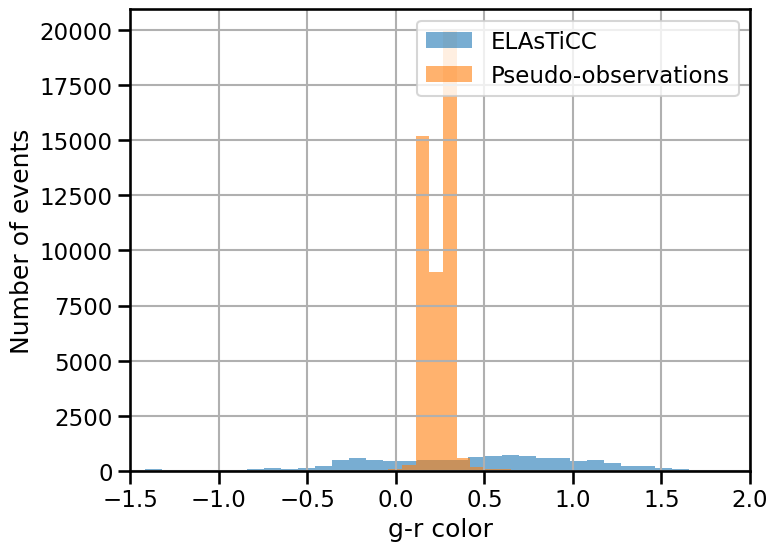

In [33]:
fig = plt.figure(figsize=(8, 6))

sub['color'].hist(bins=100, alpha=0.6, label='ELAsTiCC')
plt.hist(color, bins=100, alpha=0.6, label='Pseudo-observations');
plt.xlabel('g-r color')
plt.ylabel('Number of events')
plt.xlim(-1.5, 2)
plt.legend()

## Correlation matrices for ELAsTiCC data

/tmp/ipykernel_23494/1465304210.py:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(results.corr(), annot=True, annot_kws={"size": 18}, center=0)
/tmp/ipykernel_23494/1465304210.py:9: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  g = sns.PairGrid(results.corr(), diag_sharey=False, corner=True)


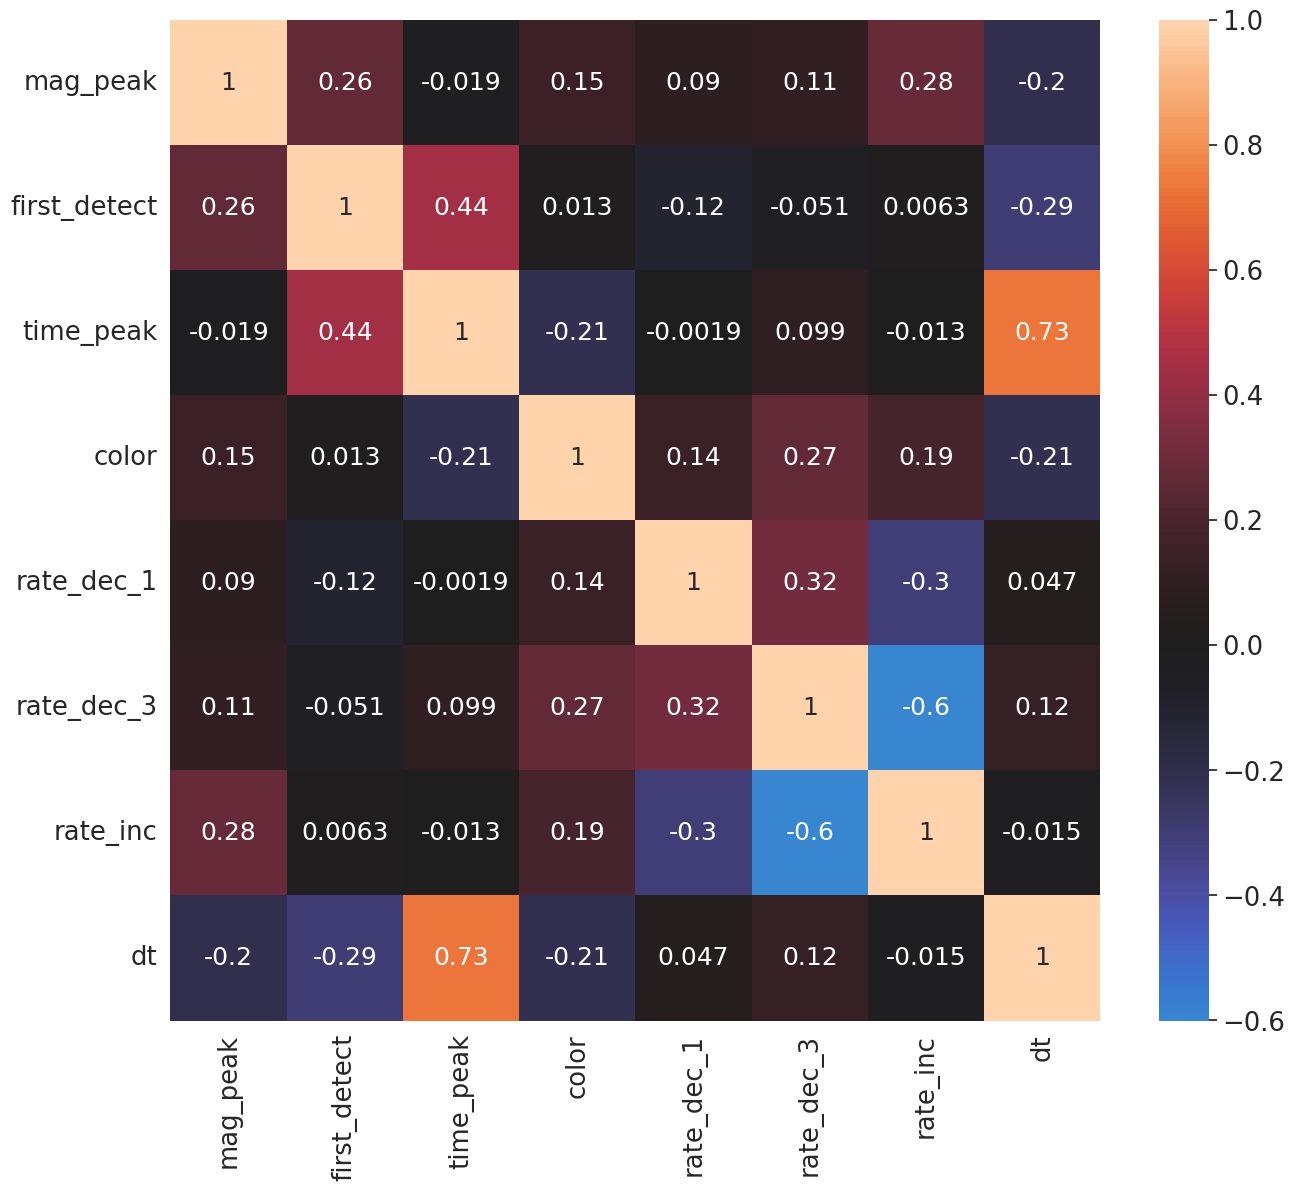

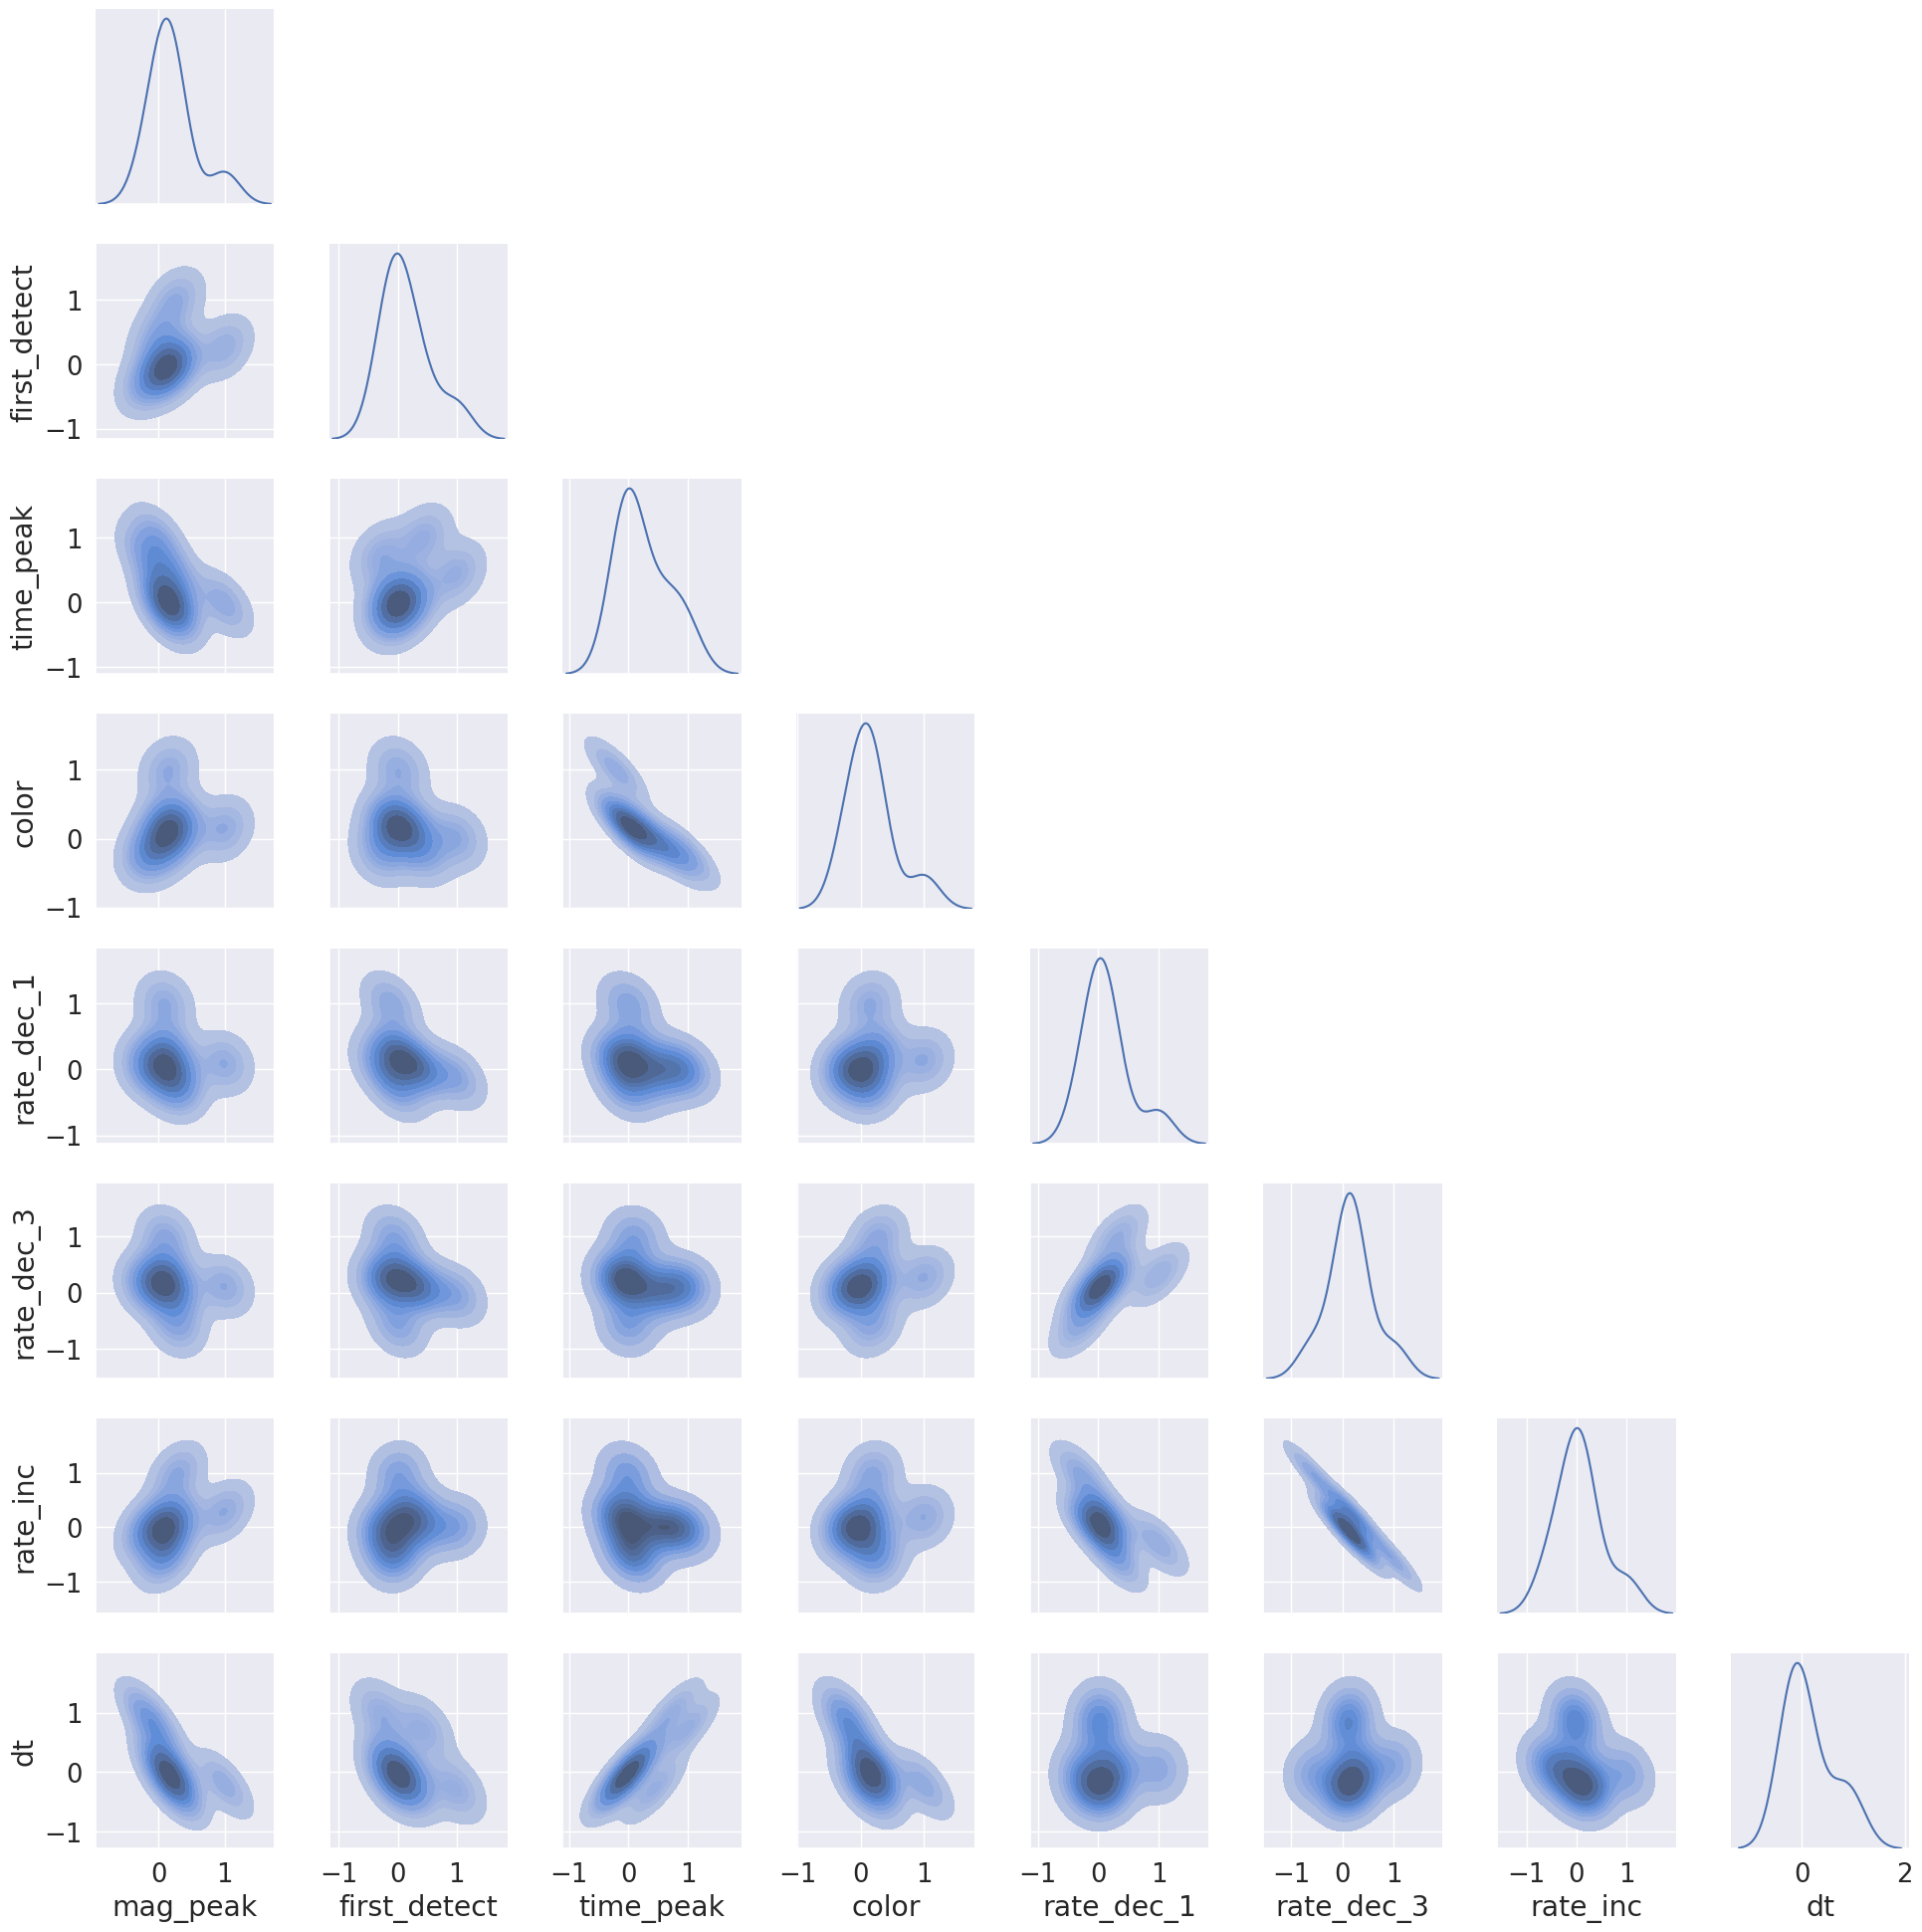

In [34]:
plt.figure(figsize=(15, 13))

# plotting the correlations between the features
results = sub.drop(['alertId', 'mags_lim'], axis=1)

sns.set(font_scale=1.7)
sns.heatmap(results.corr(), annot=True, annot_kws={"size": 18}, center=0)

g = sns.PairGrid(results.corr(), diag_sharey=False, corner=True)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.kdeplot, lw=1.5)